
===== ADJOINT METHOD =====

===== PINN METHOD =====


/home/neelan/miniconda3/envs/torch/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


PINN Iter 0 | Loss 6.138e-01
PINN Iter 500 | Loss 4.901e-03
PINN Iter 1000 | Loss 4.807e-03
PINN Iter 1500 | Loss 5.516e-03
PINN Iter 2000 | Loss 4.781e-03
PINN Iter 2500 | Loss 4.776e-03
PINN Iter 3000 | Loss 4.879e-03
PINN Iter 3500 | Loss 4.773e-03


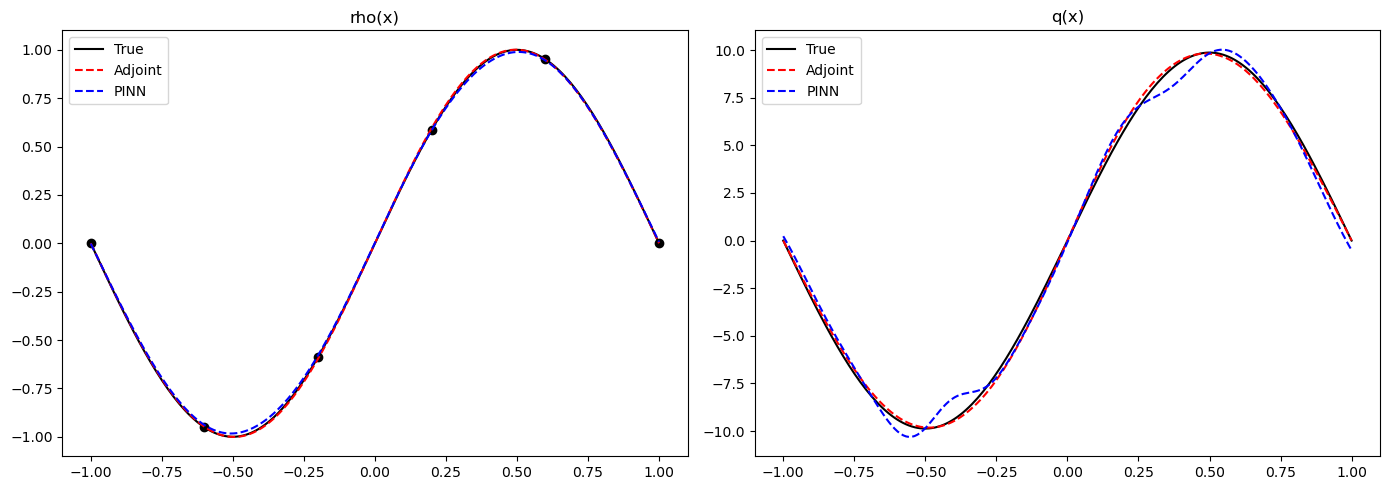

In [1]:
# %% =========================
# 0. Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import torch
import torch.nn as nn

np.random.seed(0)
torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

# %% =========================
# 1. Problem Setup
# =========================
N = 200
x = np.linspace(-1, 1, N)
dx = x[1] - x[0]

# True solution
rho_true = np.sin(np.pi * x)
q_true = (np.pi**2) * np.sin(np.pi * x)

# Sparse observations (uniform)
N_obs = 6
x_obs = np.linspace(-1, 1, N_obs)
rho_obs = np.sin(np.pi * x_obs)

obs_idx = [np.argmin(np.abs(x - xi)) for xi in x_obs]

# %% =========================
# 2. ADJOINT METHOD (H1 + L-BFGS)
# =========================
print("\n===== ADJOINT METHOD =====")

M = 80   # try 20 / 50 / 100
alpha = 1e-5

def basis(x, m):
    return np.sin(m * np.pi * (x + 1) / 2)

Phi = np.zeros((M, N))
for m in range(1, M+1):
    Phi[m-1, :] = basis(x, m)

m_vals = np.arange(1, M+1)

# Laplacian
A = np.zeros((N-2, N-2))
for i in range(N-2):
    A[i,i] = -2
    if i > 0: A[i,i-1] = 1
    if i < N-3: A[i,i+1] = 1
A /= dx**2

def objective_grad(a):

    # Forward
    q = a @ Phi
    rho = np.zeros(N)
    rho[1:-1] = np.linalg.solve(A, -q[1:-1])

    error = rho[obs_idx] - rho_obs

    data_loss = 0.5 * np.sum(error**2)
    reg_loss = 0.5 * alpha * np.sum((m_vals**2)*(a**2))
    loss = data_loss + reg_loss

    # Adjoint
    rhs = np.zeros(N)
    rhs[obs_idx] = error / dx

    lam = np.zeros(N)
    lam[1:-1] = np.linalg.solve(A, rhs[1:-1])

    grad_misfit = -(Phi @ lam) * dx
    grad_reg = alpha * (m_vals**2) * a

    return loss, grad_misfit + grad_reg

res = minimize(objective_grad,
               x0=np.zeros(M),
               method='L-BFGS-B',
               jac=True,
               options={'maxiter':500})

a_opt = res.x
q_adj = a_opt @ Phi

rho_adj = np.zeros(N)
rho_adj[1:-1] = np.linalg.solve(A, -q_adj[1:-1])

# %% =========================
# 3. PINN METHOD (ρ-based)
# =========================
print("\n===== PINN METHOD =====")

x_t = torch.tensor(x.reshape(-1,1), dtype=torch.float32, requires_grad=True).to(device)
x_obs_t = torch.tensor(x_obs.reshape(-1,1), dtype=torch.float32).to(device)
rho_obs_t = torch.tensor(rho_obs.reshape(-1,1), dtype=torch.float32).to(device)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,1)
        )
    def forward(self,x):
        return self.net(x)

model = Net().to(device)

def grad(u,x):
    return torch.autograd.grad(u,x,
        grad_outputs=torch.ones_like(u),
        create_graph=True)[0]

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training
for epoch in range(4000):

    opt.zero_grad()

    rho = model(x_t)
    rho_x = grad(rho,x_t)
    rho_xx = grad(rho_x,x_t)

    # q derived
    q = -rho_xx

    loss_data = torch.mean((model(x_obs_t)-rho_obs_t)**2)
    loss_bc = rho[0]**2 + rho[-1]**2
    loss_reg = 1e-4*torch.mean(rho_xx**2)

    loss = loss_data + loss_bc + loss_reg

    loss.backward()
    opt.step()

    if epoch % 500 == 0:
        print(f"PINN Iter {epoch} | Loss {loss.item():.3e}")

# Extract
rho_pinn = model(x_t).detach().cpu().numpy().flatten()

rho_tmp = model(x_t)
rho_x = grad(rho_tmp,x_t)
rho_xx = grad(rho_x,x_t)
q_pinn = (-rho_xx).detach().cpu().numpy().flatten()

# %% =========================
# 4. PLOT COMPARISON
# =========================
plt.figure(figsize=(14,5))

# rho
plt.subplot(1,2,1)
plt.plot(x, rho_true, 'k', label="True")
plt.plot(x, rho_adj, 'r--', label="Adjoint")
plt.plot(x, rho_pinn, 'b--', label="PINN")
plt.scatter(x_obs, rho_obs, c='black')
plt.title("rho(x)")
plt.legend()

# q
plt.subplot(1,2,2)
plt.plot(x, q_true, 'k', label="True")
plt.plot(x, q_adj, 'r--', label="Adjoint")
plt.plot(x, q_pinn, 'b--', label="PINN")
plt.title("q(x)")
plt.legend()

plt.tight_layout()
plt.show()